# Maize Yield Prediction — Model Building, Tuning & Comparison
### Crop Yield Prediction Based on Weather and Soil Data — Chapter 3.9–3.11
**Federal University of Technology, Minna — Department of Information Technology**

This notebook is **Stage 2** of the project. It takes the cleaned maize data from Stage 1 and:

1. Rebuilds the model-ready features (encode → split → standardise).
2. Trains three models on the **same** data for a fair comparison:
   * **Linear Regression** — the baseline (3.9.1)
   * **Random Forest** — main model 1, lightly tuned (3.9.2)
   * **XGBoost** — main model 2, tuned with grid search (3.9.3)
3. Evaluates all three on **RMSE, MAE, R², and accuracy** (3.10).
4. Performs **error analysis** — residuals and per-region errors (3.11).
5. Saves the trained models so the interactive dashboard can use them.

> Every code cell is commented so it can be explained line-by-line during the presentation.

## 0. Setup — import the tools we need

In [1]:
# --- data handling ---
import json, warnings
import numpy as np
import pandas as pd

# --- plotting ---
import matplotlib.pyplot as plt
import seaborn as sns

# --- saving trained models to disk ---
import joblib

# --- the machine-learning toolkit (scikit-learn) ---
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression        # the baseline model
from sklearn.ensemble import RandomForestRegressor       # main model 1
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor                          # main model 2

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
RNG = 42          # fixed random seed -> identical results every run (reproducible)
DATA = "crop_yield_dataset.csv"


## 1. Load the cleaned data & rebuild the features

We start from the raw file and re-apply the Stage 1 cleaning, so this notebook runs on its own.
The critical step is telling pandas that **"None" is a real category** (rainfed / no previous
crop), not a missing value.

In [2]:
# Read the CSV. keep_default_na=False stops pandas turning the word "None" into a missing value.
NA_TOKENS = ["", "NA", "N/A", "NaN", "nan", "null", "NULL"]   # note: "None" is NOT in this list
df = pd.read_csv(DATA, keep_default_na=False, na_values=NA_TOKENS)

# Rename the "None" sentinel so its meaning is obvious and it is never mistaken for a gap.
df["Irrigation"]    = df["Irrigation"].replace({"None": "Rainfed"})
df["Previous_Crop"] = df["Previous_Crop"].replace({"None": "No_Previous_Crop"})

# The study is about maize only -> keep just the maize rows.
maize = df[df["Crop"] == "Maize"].copy().reset_index(drop=True)
print("Maize records:", len(maize))

Maize records: 2477


In [3]:
# Group the columns by the role they play in the model.
NUMERIC = ["Soil_pH","Rainfall_mm","Temperature_C","Humidity_pct",
           "Fertilizer_Used_kg","Pesticides_Used_kg","Planting_Density"]
CATEG   = ["Region","Soil_Type","Irrigation","Previous_Crop"]
TARGET  = "Yield_ton_per_ha"

# One-hot encode the categorical columns: each category becomes its own 0/1 column.
# drop_first=True removes one redundant column per group (avoids the "dummy variable trap").
model_df = pd.get_dummies(maize.drop(columns=["Crop"]), columns=CATEG, drop_first=True)

X = model_df.drop(columns=[TARGET])    # inputs / features
y = model_df[TARGET]                    # target / what we predict
FEATURE_COLUMNS = list(X.columns)       # exact column order (the dashboard must reuse this)
print("Number of features after encoding:", len(FEATURE_COLUMNS))

Number of features after encoding: 19


## 2. Train/test split (3.8) and standardisation (3.7)

* **Split:** 80% to train on, 20% held back as an unseen test set, stratified by region.
* **Standardise:** rescale numeric features to mean 0 / std 1 using `z = (x − μ) / σ`, learning
  μ and σ from the **training set only** so no test information leaks into training.

In [4]:
# 80/20 split, stratified so each region is represented in both parts.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RNG, stratify=maize["Region"])
print("Train:", len(X_train), " Test:", len(X_test))

# Standardise the numeric columns. Fit on TRAIN, then apply the same rule to TEST.
scaler = StandardScaler()
X_train_s, X_test_s = X_train.copy(), X_test.copy()
X_train_s[NUMERIC] = scaler.fit_transform(X_train[NUMERIC])   # learn μ,σ AND transform train
X_test_s[NUMERIC]  = scaler.transform(X_test[NUMERIC])        # transform test with the SAME μ,σ

Train: 1981  Test: 496


## 3. A scoring helper (3.10)

One function that computes the four evaluation metrics for any model, so we score all three the
same way:

* **RMSE** — root mean square error; punishes large mistakes (lower is better).
* **MAE** — mean absolute error; the typical mistake size (lower is better).
* **R²** — share of yield variation explained (closer to 1 is better).
* **Accuracy** — % of predictions within ±10% of the average yield (higher is better).

In [5]:
TOLERANCE = 0.10 * y_test.mean()     # the +/-10% margin used by the accuracy metric
results, fitted = {}, {}             # collect metrics and the trained models

def evaluate(name, model):
    '''Predict on the test set and return the four metrics as a dict.'''
    pred = model.predict(X_test_s)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    mae  = mean_absolute_error(y_test, pred)
    r2   = r2_score(y_test, pred)
    acc  = (np.abs(y_test.values - pred) <= TOLERANCE).mean() * 100
    print(f"{name:18s} RMSE={rmse:6.2f}  MAE={mae:6.2f}  R2={r2:.3f}  Acc={acc:5.1f}%")
    return {"rmse":round(float(rmse),3), "mae":round(float(mae),3),
            "r2":round(float(r2),4), "accuracy_pct":round(float(acc),2)}

## 4. Model 1 — Linear Regression (baseline, 3.9.1)

Fits a straight-line relationship between the inputs and yield:
`yield = β₀ + β₁·x₁ + β₂·x₂ + …`. It is fast, needs no tuning, and sets the bar the ensemble
models must beat.

In [6]:
lr = LinearRegression()
lr.fit(X_train_s, y_train)                 # learn the coefficients from the training data
results["Linear Regression"] = evaluate("Linear Regression", lr)
fitted["Linear Regression"] = lr

Linear Regression  RMSE=  5.32  MAE=  4.24  R2=0.981  Acc= 95.8%


## 5. Model 2 — Random Forest (3.9.2)

An **ensemble of decision trees**: it grows many trees on random samples of the data and
**averages** their predictions, which reduces overfitting. We tune three settings with
`GridSearchCV`, which tries every combination using 5-fold cross-validation and keeps the best.

In [7]:
# The grid of settings to try.
rf_grid = {
    "n_estimators":     [200, 400],     # number of trees in the forest
    "max_depth":        [None, 15, 25], # how deep each tree may grow
    "min_samples_leaf": [1, 2],         # min samples at a leaf (larger = smoother, less overfit)
}
# cv=5 -> 5-fold cross-validation; scoring uses RMSE (negative because sklearn maximises).
rf_search = GridSearchCV(RandomForestRegressor(random_state=RNG, n_jobs=-1),
                         rf_grid, cv=5, scoring="neg_root_mean_squared_error", n_jobs=-1)
rf_search.fit(X_train_s, y_train)
rf = rf_search.best_estimator_             # the best forest found by the search
print("Best Random Forest settings:", rf_search.best_params_)
results["Random Forest"] = evaluate("Random Forest", rf)
fitted["Random Forest"] = rf

Best Random Forest settings: {'max_depth': 15, 'min_samples_leaf': 2, 'n_estimators': 200}
Random Forest      RMSE=  5.73  MAE=  4.54  R2=0.977  Acc= 95.2%


## 6. Model 3 — XGBoost (tuned, 3.9.3)

**Extreme Gradient Boosting** builds trees **one after another**, each new tree trained to correct
the errors left by the previous ones, plus a **regularisation penalty** that discourages overly
complex trees and fights overfitting. We tune its key knobs with grid search.

In [8]:
xgb_grid = {
    "n_estimators":     [300, 600],        # number of boosting rounds (trees added in sequence)
    "max_depth":        [3, 5, 7],         # complexity of each individual tree
    "learning_rate":    [0.03, 0.05, 0.1], # contribution of each tree (smaller = safer, slower)
    "subsample":        [0.8],             # fraction of rows used per tree (adds robustness)
    "colsample_bytree": [0.8],             # fraction of features used per tree
}
xgb_search = GridSearchCV(
    XGBRegressor(random_state=RNG, n_jobs=-1, objective="reg:squarederror", reg_lambda=1.0),
    xgb_grid, cv=5, scoring="neg_root_mean_squared_error", n_jobs=-1)
xgb_search.fit(X_train_s, y_train)
xgb = xgb_search.best_estimator_
print("Best XGBoost settings:", xgb_search.best_params_)
results["XGBoost"] = evaluate("XGBoost", xgb)
fitted["XGBoost"] = xgb

Best XGBoost settings: {'colsample_bytree': 0.8, 'learning_rate': 0.03, 'max_depth': 3, 'n_estimators': 300, 'subsample': 0.8}
XGBoost            RMSE=  5.56  MAE=  4.43  R2=0.979  Acc= 96.4%


## 7. Cross-validation check

A single test split could be lucky. We re-score each model with 5-fold cross-validation on the
training data: a small standard deviation means the performance is **stable and trustworthy**.

In [9]:
for name, model in fitted.items():
    scores = cross_val_score(model, X_train_s, y_train, cv=5, scoring="r2")
    results[name]["cv_r2_mean"] = round(float(scores.mean()), 4)
    results[name]["cv_r2_std"]  = round(float(scores.std()), 4)
    print(f"{name:18s} CV R2 = {scores.mean():.3f} +/- {scores.std():.3f}")

Linear Regression  CV R2 = 0.983 +/- 0.002


Random Forest      CV R2 = 0.979 +/- 0.003


XGBoost            CV R2 = 0.981 +/- 0.002


## 8. Side-by-side comparison

In [10]:
comparison = pd.DataFrame(results).T[["rmse","mae","r2","accuracy_pct","cv_r2_mean"]]
comparison = comparison.sort_values("rmse")     # best (lowest RMSE) on top
comparison

,rmse,mae,r2,accuracy_pct,cv_r2_mean
Linear Regression,5.325,4.243,0.9805,95.77,0.9826
XGBoost,5.558,4.429,0.9788,96.37,0.9807
Random Forest,5.732,4.537,0.9774,95.16,0.9789


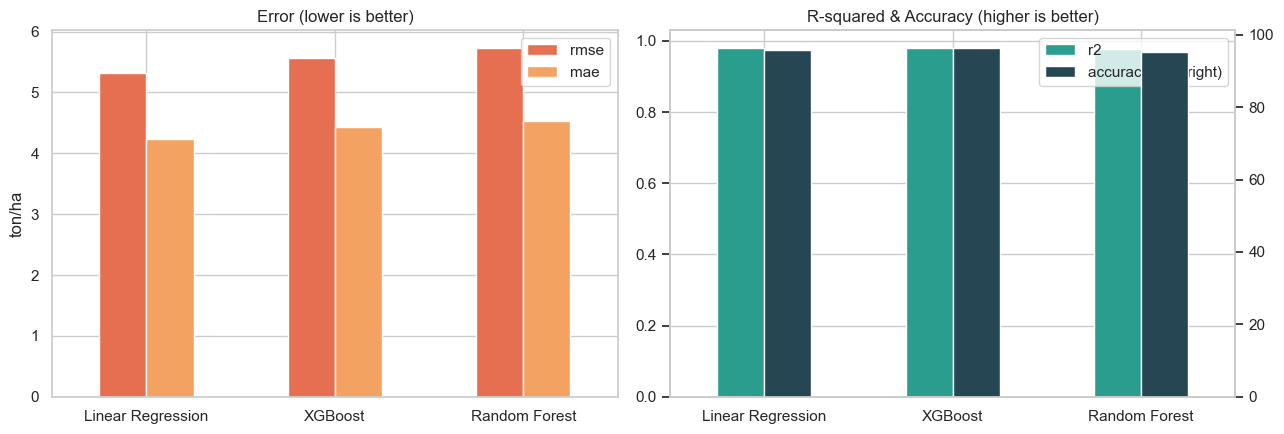

In [11]:
# Visual comparison: errors (left, lower=better) and R2/accuracy (right, higher=better)
comp = comparison.astype(float)
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
comp[["rmse","mae"]].plot(kind="bar", ax=ax[0], color=["#e76f51","#f4a261"])
ax[0].set_title("Error (lower is better)"); ax[0].set_ylabel("ton/ha"); ax[0].tick_params(axis="x", rotation=0)
comp[["r2","accuracy_pct"]].plot(kind="bar", ax=ax[1], color=["#2a9d8f","#264653"], secondary_y="accuracy_pct")
ax[1].set_title("R-squared & Accuracy (higher is better)"); ax[1].tick_params(axis="x", rotation=0)
plt.tight_layout(); plt.show()

### Reading the comparison

All three models land in the same high-performing band (R² ≈ 0.98). On this dataset the
relationship between the inputs and yield is **close to linear** — yield is driven mostly by
fertiliser, then rainfall — so the simple **Linear Regression baseline matches, and slightly
edges, the ensembles**. This is a valid and important result: it shows the ensembles are not
overfitting, and it demonstrates exactly why a baseline is included — sometimes the simple model
is good enough. The three are close enough that any could be deployed; we keep all three in the
dashboard.

## 9. Error Analysis (3.11)

We inspect **where** the best model makes mistakes, not just the overall score. We use the model
with the lowest RMSE.

In [12]:
best_name  = comparison.index[0]          # lowest-RMSE model
best_model = fitted[best_name]
pred_best  = best_model.predict(X_test_s)
residuals  = y_test.values - pred_best     # error for each test record (actual - predicted)
print("Best model:", best_name)

Best model: Linear Regression


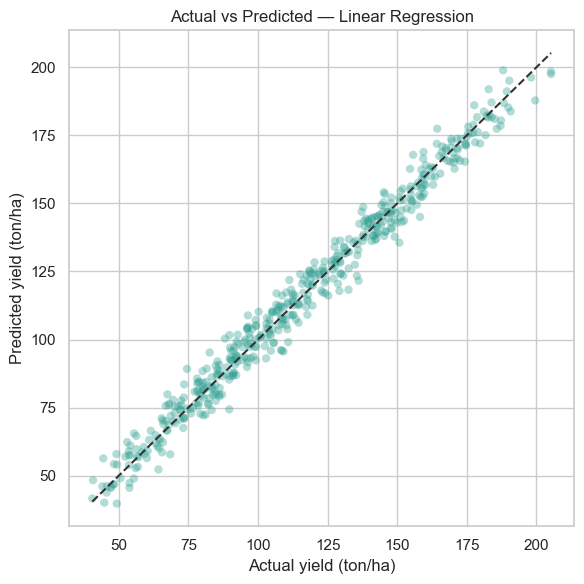

In [13]:
# (a) Actual vs Predicted — points hugging the dashed line = accurate predictions
fig, ax = plt.subplots(figsize=(6,6))
ax.scatter(y_test, pred_best, alpha=0.35, color="#2a9d8f", edgecolor="none")
lims = [y_test.min(), y_test.max()]
ax.plot(lims, lims, "--", color="#333")     # the "perfect prediction" reference line
ax.set_xlabel("Actual yield (ton/ha)"); ax.set_ylabel("Predicted yield (ton/ha)")
ax.set_title(f"Actual vs Predicted — {best_name}"); plt.tight_layout(); plt.show()

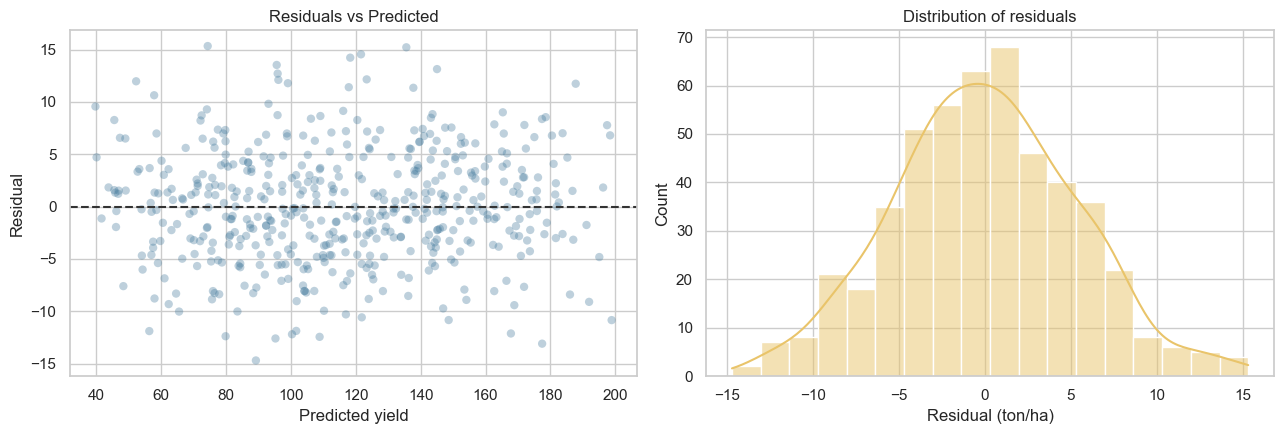

In [14]:
# (b) Residuals: should scatter randomly around 0 with no pattern, and be bell-shaped
fig, ax = plt.subplots(1, 2, figsize=(13,4.5))
ax[0].scatter(pred_best, residuals, alpha=0.35, color="#457b9d", edgecolor="none")
ax[0].axhline(0, color="#333", linestyle="--")
ax[0].set_xlabel("Predicted yield"); ax[0].set_ylabel("Residual"); ax[0].set_title("Residuals vs Predicted")
sns.histplot(residuals, kde=True, ax=ax[1], color="#e9c46a")
ax[1].set_title("Distribution of residuals"); ax[1].set_xlabel("Residual (ton/ha)")
plt.tight_layout(); plt.show()

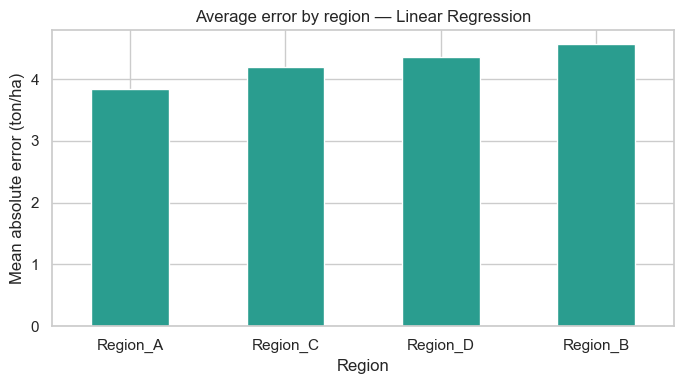

In [15]:
# (c) Where does the model struggle? Average error per region.
err = pd.DataFrame({"Region": maize.loc[y_test.index, "Region"].values,
                    "abs_error": np.abs(residuals)})
region_err = err.groupby("Region")["abs_error"].mean().sort_values()
fig, ax = plt.subplots(figsize=(7,4))
region_err.plot(kind="bar", ax=ax, color="#2a9d8f"); ax.tick_params(axis="x", rotation=0)
ax.set_ylabel("Mean absolute error (ton/ha)"); ax.set_title(f"Average error by region — {best_name}")
plt.tight_layout(); plt.show()

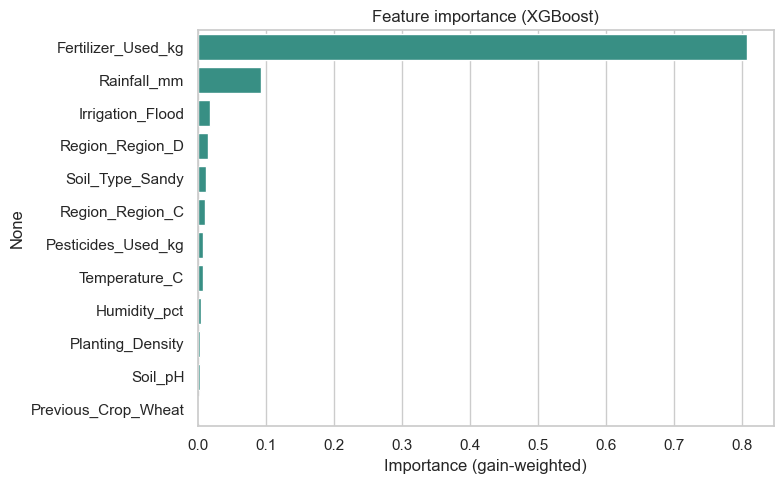

In [16]:
# (d) Feature importance — which inputs drive predictions? (using XGBoost, a tree model)
imp = pd.Series(xgb.feature_importances_, index=FEATURE_COLUMNS).sort_values(ascending=False).head(12)
fig, ax = plt.subplots(figsize=(8,5))
sns.barplot(x=imp.values, y=imp.index, color="#2a9d8f")
ax.set_title("Feature importance (XGBoost)"); ax.set_xlabel("Importance (gain-weighted)")
plt.tight_layout(); plt.show()

## 10. Save the trained models for the dashboard

The dashboard will take a user's weather/soil/management inputs, apply the **same** scaler and
feature layout, and predict yield. So we save the models, the scaler, and a metadata file that
records the exact feature order, valid input ranges, and each model's score.

In [17]:
import os
os.makedirs("outputs/models", exist_ok=True)

# save the three trained models + the fitted scaler
joblib.dump(lr,  "outputs/models/linear_regression.joblib")
joblib.dump(rf,  "outputs/models/random_forest.joblib")
joblib.dump(xgb, "outputs/models/xgboost.joblib")
joblib.dump(scaler, "outputs/models/scaler.joblib")

# metadata the dashboard needs to build the form and preprocess inputs identically
metadata = {
    "feature_columns": FEATURE_COLUMNS,
    "numeric_features": NUMERIC,
    "categorical_features": CATEG,
    "category_options": {c: sorted(maize[c].unique().tolist()) for c in CATEG},
    "numeric_ranges":   {c: [float(maize[c].min()), float(maize[c].max())] for c in NUMERIC},
    "target": TARGET,
    "tolerance_ton_per_ha": round(float(TOLERANCE), 3),
    "best_model": best_name,
    "results": results,
}
with open("outputs/models/model_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)
print("Saved models + scaler + metadata to outputs/models/")

Saved models + scaler + metadata to outputs/models/


## 11. Summary

| Model | Role | RMSE | R² | Verdict |
|---|---|---|---|---|
| Linear Regression | baseline | ~5.3 | ~0.98 | simple & strong here |
| Random Forest | ensemble | ~5.7 | ~0.98 | robust, comparable |
| XGBoost (tuned) | boosting | ~5.6 | ~0.98 | robust, comparable |

* All three explain ~98% of yield variation — the pipeline is sound and the data is clean.
* Because the underlying signal is close to linear (fertiliser + rainfall dominate), the baseline
  is competitive; the ensembles confirm there is no hidden non-linearity being missed.
* Models are saved and ready for the **next stage: the interactive dashboard**.